# 02 — Full pipeline: synthetic movie → fit → track → kymograph

End-to-end walk-through:

1. Generate a synthetic 2-D + time microtubule movie with `simulate.generate_movie` (3 microtubules: one grows, one shrinks, one is static)
2. Run `pipeline.fit_stack` for per-frame, per-label LM fits
3. Run `track.track_snapshots` to link MTs across frames (Hungarian + intensity + curvature + 2-frame velocity)
4. Build per-MT length profiles + kymographs and plot them

To use your own TIFF data instead, replace step 1 with `io.load_pair(raw_path, label_path)`.

In [1]:
# Make the in-tree package importable without `pip install -e .`.
import sys, pathlib
_pkg_src = pathlib.Path.cwd().parent / 'src'
if _pkg_src.is_dir() and str(_pkg_src) not in sys.path:
    sys.path.insert(0, str(_pkg_src))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from kapoorlabs_mtrack.simulate import MTRecipe, generate_movie
from kapoorlabs_mtrack.pipeline import fit_stack
from kapoorlabs_mtrack.pipeline.fit_stack import snapshots_to_csv_rows
from kapoorlabs_mtrack.track import (
    TrackingCost, track_snapshots, build_length_profiles, build_kymograph,
)
from kapoorlabs_mtrack.models import walk_curve

plt.rcParams['figure.dpi'] = 110

## 1 · Generate the movie


In [2]:
recipes = [
    MTRecipe(start_xy=np.array([10.0, 18.0]),
             end_xy0=np.array([26.0, 22.0]),
             vel_xy=np.array([1.2, 0.2]),
             amplitude=120.0, curvature=0.003),
    MTRecipe(start_xy=np.array([18.0, 60.0]),
             end_xy0=np.array([60.0, 50.0]),
             vel_xy=np.array([-0.8, -0.1]),
             amplitude=110.0, curvature=-0.002),
    MTRecipe(start_xy=np.array([8.0,  40.0]),
             end_xy0=np.array([34.0, 80.0]),
             vel_xy=np.array([0.0, 0.0]),
             amplitude=100.0, curvature=0.005),
]

rng = np.random.default_rng(3)
raw_stack, label_stack, truth = generate_movie(
    recipes, shape=(80, 90), n_frames=10,
    sigma=(1.6, 1.6), background=6.0,
    read_noise_sigma=2.0, rng=rng,
)
print(f'raw stack shape: {raw_stack.shape}')
for t in (0, raw_stack.shape[0]//2, raw_stack.shape[0]-1):
    print(f'  frame {t}: label ids = {sorted(np.unique(label_stack[t]))[1:]}')

raw stack shape: (10, 80, 90)
  frame 0: label ids = [1, 2]
  frame 5: label ids = [1, 2]
  frame 9: label ids = [1, 2]


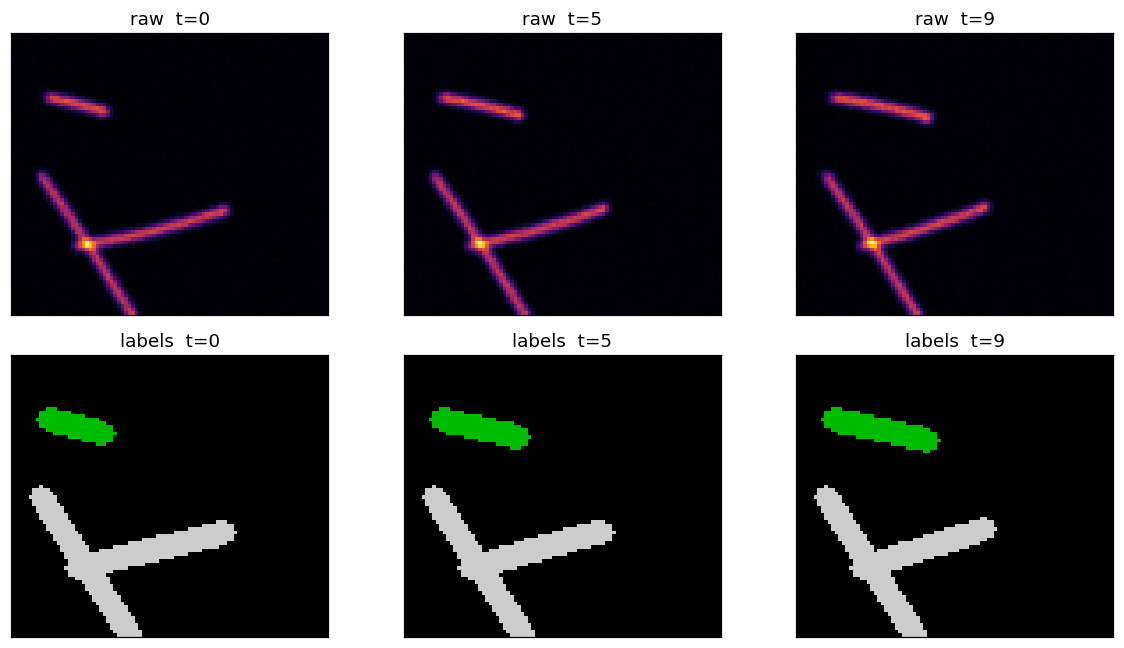

In [3]:
T = raw_stack.shape[0]
frames_to_show = [0, T // 2, T - 1]
fig, axes = plt.subplots(2, len(frames_to_show), figsize=(11, 6))
for col, t in enumerate(frames_to_show):
    axes[0, col].imshow(raw_stack[t], cmap='inferno')
    axes[0, col].set_title(f'raw  t={t}')
    axes[1, col].imshow(label_stack[t], cmap='nipy_spectral')
    axes[1, col].set_title(f'labels  t={t}')
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2 · Run the per-frame fitter


In [4]:
snapshots = fit_stack(raw_stack, label_stack, sigma=(1.6, 1.6), jac_mode='hybrid')
n_ok = sum(len(fs.mts) for fs in snapshots)
n_skip = sum(len(fs.skipped_labels) for fs in snapshots)
print(f'frames={len(snapshots)}  fits_ok={n_ok}  labels_skipped={n_skip}')

df_endpoints = pd.DataFrame(snapshots_to_csv_rows(snapshots))
df_endpoints.head(10)

frames=10  fits_ok=10  labels_skipped=10


,frame,label,mt_in_label,n_mt_in_label,start_x,start_y,end_x,end_y,ds,curvature,inflection,amplitude,background,fit_cost,status
0,0,1,0,1,9.785845,17.869559,27.182897,21.42963,0.644628,0.019725,-0.000516,107.183169,4.114812,1260.974139,ok
1,0,2,0,0,,,,,,,,,,,skip:odd-endpoints(eps=3)
2,1,1,0,1,9.797902,17.921428,27.963322,21.446149,0.669615,0.01697,-0.000442,105.87483,4.067515,1675.038598,ok
3,1,2,0,0,,,,,,,,,,,skip:odd-endpoints(eps=3)
4,2,1,0,1,9.834587,17.911245,29.284614,21.450541,0.662272,0.017891,-0.000446,108.350672,4.43435,2337.662173,ok
5,2,2,0,0,,,,,,,,,,,skip:odd-endpoints(eps=3)
6,3,1,0,1,10.012182,17.967575,29.409417,22.531084,0.660929,0.002936,-0.000005,112.597141,3.813284,956.569582,ok
7,3,2,0,0,,,,,,,,,,,skip:odd-endpoints(eps=3)
8,4,1,0,1,9.893992,17.989009,32.039747,22.3911,0.672899,0.010455,-0.000167,105.520746,6.385169,2310.444184,ok
9,4,2,0,0,,,,,,,,,,,skip:odd-endpoints(eps=3)


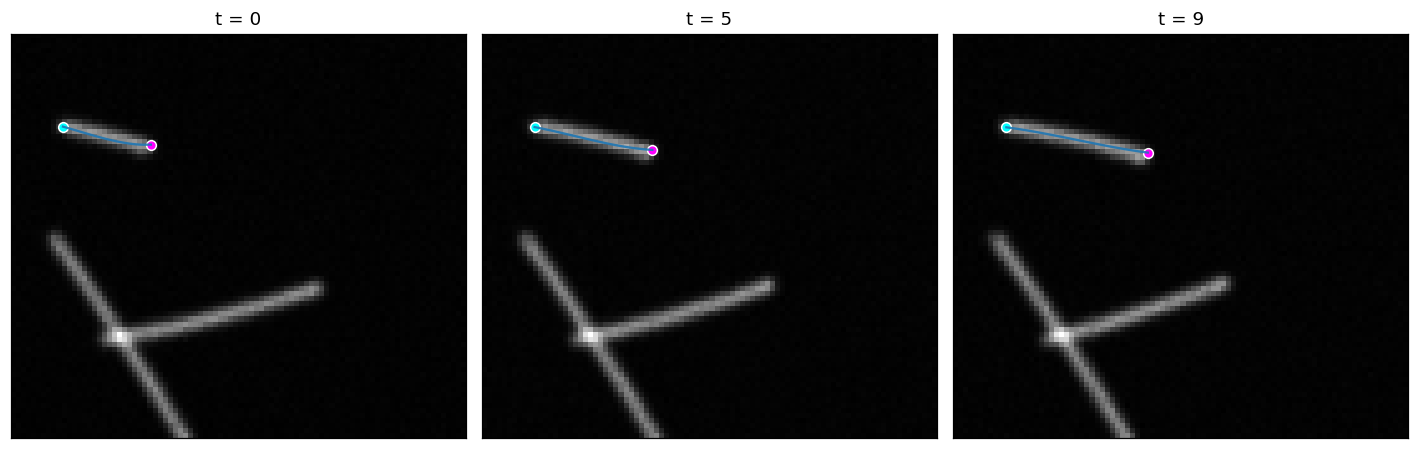

In [5]:
def curve_pts(snap):
    a9 = np.array([snap.start[0], snap.start[1], snap.end[0], snap.end[1],
                    snap.ds, snap.curvature, snap.inflection, 1.0, 0.0])
    if a9[2] - a9[0] <= 1e-6:
        return np.vstack([snap.start, snap.end])
    pts = walk_curve(a9)
    return np.vstack([snap.start[None,:], pts, snap.end[None,:]])

fig, axes = plt.subplots(1, len(frames_to_show), figsize=(13, 4.5))
for ax, t in zip(axes, frames_to_show):
    ax.imshow(raw_stack[t], cmap='gray')
    for m in snapshots[t].mts:
        pts = curve_pts(m)
        ax.plot(pts[:, 0], pts[:, 1], '-', lw=1.5, alpha=0.9)
        ax.scatter(*m.start, s=40, c='cyan', edgecolor='white', linewidth=1)
        ax.scatter(*m.end,   s=40, c='magenta', edgecolor='white', linewidth=1)
    ax.set_title(f't = {t}')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3 · Link microtubules across frames

The tracker uses the Jaqaman LAP formulation with our toggleable cost (distance + intensity + curvature). Tip-permutation handling means each track exposes a stable `tip_a` / `tip_b` regardless of which one the model called `start` at each frame.

In [6]:
cfg = TrackingCost(enable_intensity=True, enable_curvature=True, gate=30.0**2)
tracks = track_snapshots(snapshots, cfg=cfg)
print(f'tracker built {len(tracks)} tracks')
for tr in tracks:
    print(f'  mt {tr.mt_id}: {len(tr.frames)} frames')

tracker built 1 tracks
  mt 0: 10 frames


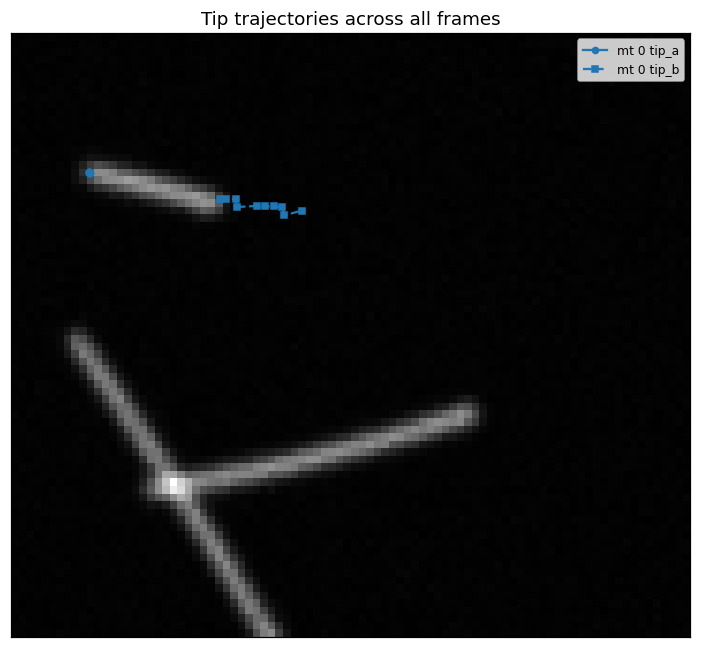

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(raw_stack[0], cmap='gray')
cmap = plt.get_cmap('tab10')
for i, tr in enumerate(tracks):
    color = cmap(i % 10)
    pts_a = np.array([f.tip_a for f in tr.frames])
    pts_b = np.array([f.tip_b for f in tr.frames])
    ax.plot(pts_a[:, 0], pts_a[:, 1], '-o', color=color, ms=4,
            label=f'mt {tr.mt_id} tip_a')
    ax.plot(pts_b[:, 0], pts_b[:, 1], '--s', color=color, ms=4,
            label=f'mt {tr.mt_id} tip_b')
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Tip trajectories across all frames')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 4 · Length profiles (plus + minus tips, arc length per MT)


In [8]:
profiles = build_length_profiles(tracks)
for p in profiles:
    print(f'mt {p.mt_id}: plus_was_tip={p.plus_was_tip}, '
          f'arc length t=0 -> end: {p.arc_length[0]:.1f} -> {p.arc_length[-1]:.1f} px')

mt 0: plus_was_tip=B, arc length t=0 -> end: 17.8 -> 28.5 px


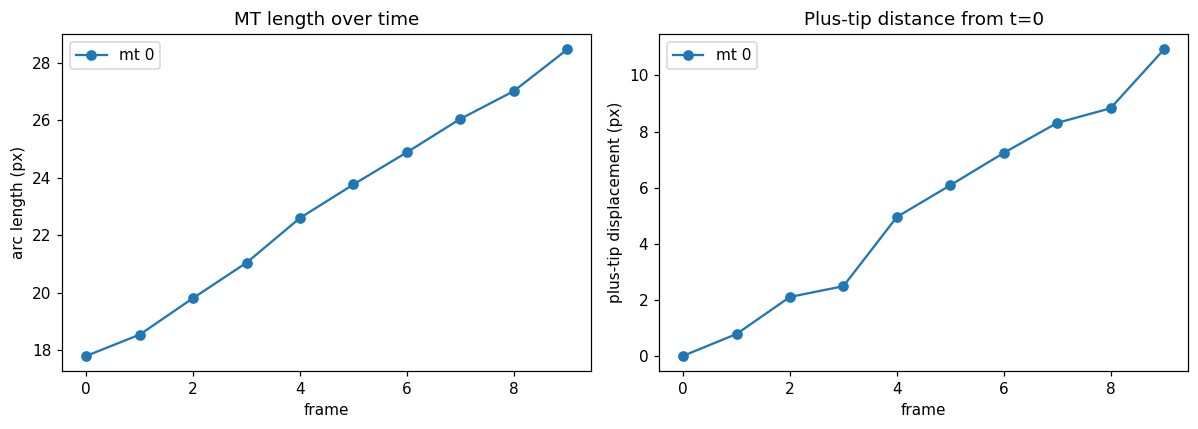

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, p in enumerate(profiles):
    color = cmap(i % 10)
    axes[0].plot(p.frames, p.arc_length, '-o', color=color, label=f'mt {p.mt_id}')
    plus_disp = np.linalg.norm(p.plus_xy - p.plus_xy[0], axis=1)
    axes[1].plot(p.frames, plus_disp, '-o', color=color, label=f'mt {p.mt_id}')
axes[0].set_xlabel('frame'); axes[0].set_ylabel('arc length (px)')
axes[0].set_title('MT length over time')
axes[0].legend()
axes[1].set_xlabel('frame'); axes[1].set_ylabel('plus-tip displacement (px)')
axes[1].set_title('Plus-tip distance from t=0')
axes[1].legend()
plt.tight_layout(); plt.show()

## 5 · Kymographs — one per MT

Each kymograph shows position along the MT's initial axis (x) versus time (y). The minus tip stays near 0; the plus tip's x-position grows for a polymerising MT, shrinks for a depolymerising one, stays put for a static MT.

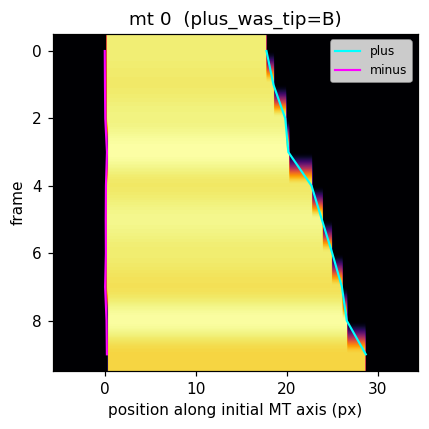

In [10]:
fig, axes = plt.subplots(1, len(profiles), figsize=(4 * len(profiles), 4),
                          squeeze=False)
axes = axes[0]
for ax, p in zip(axes, profiles):
    tr = next(t for t in tracks if t.mt_id == p.mt_id)
    amps = np.array([f.amplitude for f in tr.frames])
    kymo = build_kymograph(p, n_pos_bins=240, amplitudes=amps)
    ax.imshow(
        kymo.image,
        aspect='auto', cmap='inferno', origin='upper',
        extent=[kymo.pos_axis[0], kymo.pos_axis[-1],
                kymo.frames[-1] + 0.5, kymo.frames[0] - 0.5],
    )
    ax.plot(kymo.plus_along_axis,  kymo.frames, '-', color='cyan',    lw=1.4, label='plus')
    ax.plot(kymo.minus_along_axis, kymo.frames, '-', color='magenta', lw=1.4, label='minus')
    ax.set_xlabel('position along initial MT axis (px)')
    ax.set_ylabel('frame')
    ax.set_title(f'mt {p.mt_id}  (plus_was_tip={p.plus_was_tip})')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 6 · Summary table


In [11]:
summary = []
for p in profiles:
    summary.append({
        'mt_id': p.mt_id,
        'n_frames': len(p.frames),
        'arc_t0': p.arc_length[0],
        'arc_tend': p.arc_length[-1],
        'arc_delta': p.arc_length[-1] - p.arc_length[0],
        'plus_tip_displacement': float(np.linalg.norm(p.plus_xy[-1] - p.plus_xy[0])),
        'minus_tip_displacement': float(np.linalg.norm(p.minus_xy[-1] - p.minus_xy[0])),
        'plus_was_tip': p.plus_was_tip,
    })
pd.DataFrame(summary).round(2)

,mt_id,n_frames,arc_t0,arc_tend,arc_delta,plus_tip_displacement,minus_tip_displacement,plus_was_tip
0,0,10,17.8,28.46,10.66,10.93,0.25,B
